In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost

print("Libraries Imported Successful ✅")

Libraries Imported Successful ✅



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv("../data/dataset.csv")
print("Dataset Loaded Successfully ✅")
df.shape

Dataset Loaded Successfully ✅


(1500, 12)

In [3]:
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [4]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   str    
 1   Crop               1500 non-null   str    
 2   Soil_Type          1500 non-null   str    
 3   Fertilizer         1500 non-null   str    
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 140.8 KB


In [5]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,73.438000,61.282667,102.112667,176.806000,28.148547,7881.892667,6.766347,2012.090000
std,37.756932,33.257422,54.362863,73.776182,5.783160,20073.333665,0.724898,7.393218
min,10.000000,5.000000,10.000000,50.000000,18.020000,502.000000,5.500000,2000.000000
25%,41.000000,33.000000,56.000000,113.000000,23.132500,1202.750000,6.120000,2005.000000
50%,70.000000,61.000000,100.000000,176.000000,28.490000,1673.500000,6.795000,2012.000000
75%,106.000000,91.000000,149.000000,242.000000,33.180000,2571.750000,7.400000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,89946.000000,8.000000,2024.000000


In [6]:

df.isnull().sum()

State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0
dtype: int64

In [7]:

df = df.drop_duplicates()



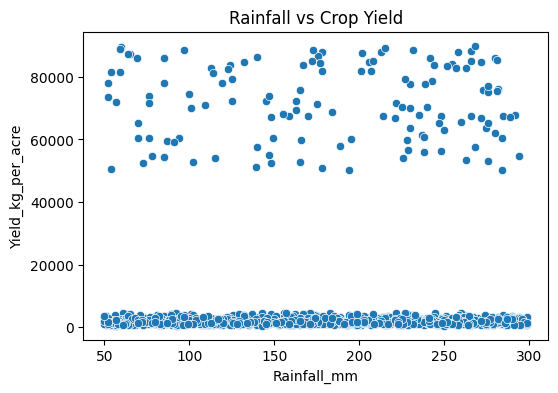

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Rainfall_mm', y='Yield_kg_per_acre', data=df)
plt.title("Rainfall vs Crop Yield")
plt.show()

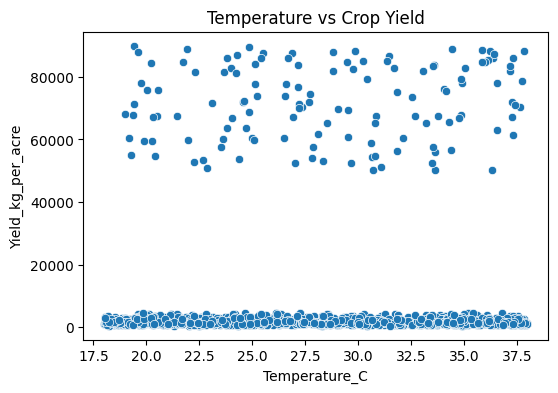

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Temperature_C', y='Yield_kg_per_acre', data=df)
plt.title("Temperature vs Crop Yield")
plt.show()

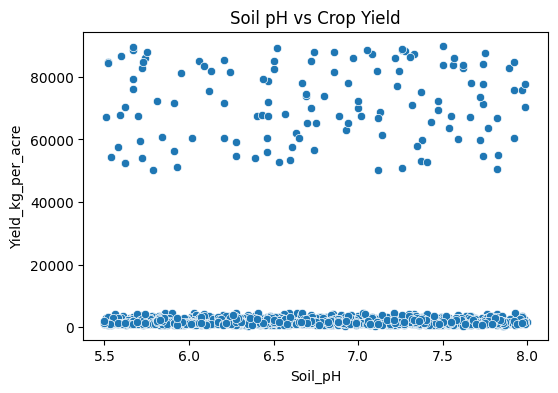

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Soil_pH', y='Yield_kg_per_acre', data=df)
plt.title("Soil pH vs Crop Yield")
plt.show()

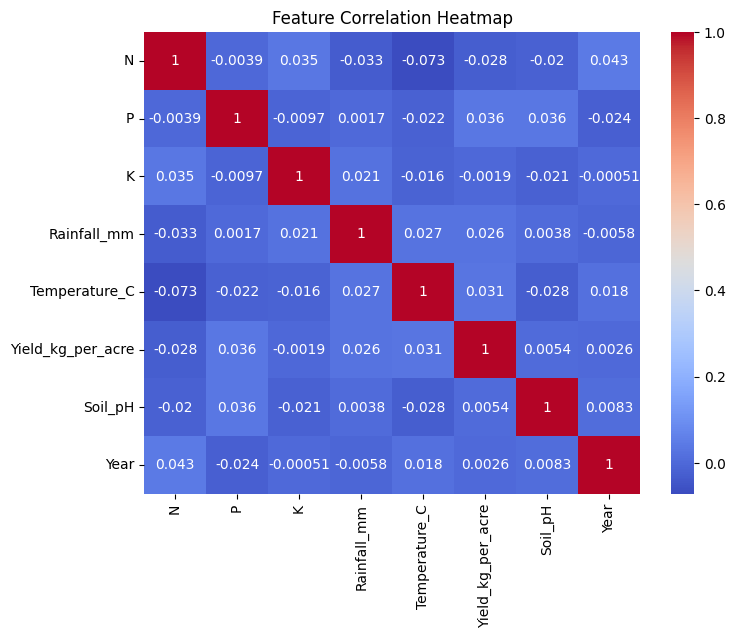

In [11]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

yield_corr = corr["Yield_kg_per_acre"].sort_values(ascending=False)

print("Correlation with Yield:")
print(yield_corr)

Correlation with Yield:
Yield_kg_per_acre    1.000000
P                    0.035973
Temperature_C        0.031302
Rainfall_mm          0.025956
Soil_pH              0.005441
Year                 0.002626
K                   -0.001884
N                   -0.028124
Name: Yield_kg_per_acre, dtype: float64


In [13]:
df.select_dtypes(include=['object']).columns

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4424\549554427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['State', 'Crop', 'Soil_Type', 'Fertilizer'], dtype='str')

In [14]:

df["NPK_Index"] = df["N"] + df["P"] + df["K"]
df["Climate_Index"] = df["Rainfall_mm"] * df["Temperature_C"]
df["Soil_Health_Index"] = df["Soil_pH"] * df["NPK_Index"]

print("New features engineered! ✅")
df.head()

New features engineered! ✅


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year,NPK_Index,Climate_Index,Soil_Health_Index
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003,188,3820.38,1282.16
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002,177,8390.59,1134.57
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015,252,3437.82,1779.12
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022,264,7002.95,1565.52
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017,232,9944.03,1447.68


In [15]:

df_encoded = pd.get_dummies(df, columns=['State', 'Crop', 'Soil_Type', 'Fertilizer'], drop_first=True)

df_encoded.head()

,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year,NPK_Index,Climate_Index,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,96,41,51,123,31.06,1899,6.82,2003,188,3820.38,...,False,False,True,False,False,True,False,False,False,False
1,29,36,112,247,33.97,1002,6.41,2002,177,8390.59,...,False,False,False,True,False,False,False,False,False,True
2,37,38,177,142,24.21,1465,7.06,2015,252,3437.82,...,False,False,False,True,False,False,False,False,False,False
3,58,77,129,227,30.85,2273,5.93,2022,264,7002.95,...,True,False,False,True,False,False,False,False,False,False
4,108,61,63,263,37.81,1497,6.24,2017,232,9944.03,...,False,True,False,False,False,False,False,True,False,False


In [16]:
y = df_encoded["Yield_kg_per_acre"]

X = df_encoded.drop("Yield_kg_per_acre", axis=1)

print("Features and Target separated! ✅")

Features and Target separated! ✅


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("Data Scaling Completed Successfully! 🚀")
X_final.head()

Data Scaling Completed Successfully! 🚀


,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,NPK_Index,Climate_Index,Soil_Health_Index,...,Crop_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Potash,Fertilizer_Urea
0,0.597758,-0.610072,-0.940526,-0.729557,0.503604,0.074040,-1.229915,-0.653532,-0.493706,-0.600250,...,-0.344337,-0.539331,2.082805,-0.496873,-0.473804,2.209605,-0.426653,-0.445065,-0.45043,-0.455773
1,-1.177342,-0.760465,0.181937,0.951763,1.006957,-0.491746,-1.365219,-0.800744,1.438192,-0.877254,...,-0.344337,-0.539331,-0.480122,2.012587,-0.473804,-0.452570,-0.426653,-0.445065,-0.45043,2.194072
2,-0.965390,-0.700308,1.378005,-0.471936,-0.681264,0.405231,0.393735,0.202974,-0.655420,0.332469,...,-0.344337,-0.539331,-0.480122,2.012587,-0.473804,-0.452570,-0.426653,-0.445065,-0.45043,-0.455773
3,-0.409015,0.472754,0.494755,0.680582,0.467280,-1.154129,1.340865,0.363569,0.851615,-0.068426,...,2.904128,-0.539331,-0.480122,2.012587,-0.473804,-0.452570,-0.426653,-0.445065,-0.45043,-0.455773
4,0.915687,-0.008502,-0.719714,1.168707,1.671175,-0.726340,0.664344,-0.064684,2.094855,-0.289593,...,-0.344337,1.854149,-0.480122,-0.496873,-0.473804,-0.452570,-0.426653,2.246862,-0.45043,-0.455773


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
print("Data splitting completed! ✅")

Data splitting completed! ✅


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=5, scoring='r2')
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("GridSearchCV training with 5-fold CV completed! 🚀")

GridSearchCV training with 5-fold CV completed! 🚀


In [20]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate(model, name):
    predictions = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    print(f"--- {name} Results ---")
    print(f"R² Score (Accuracy): {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}\n")

evaluate(lr_model, "Linear Regression")
evaluate(best_rf, "Random Forest (Tuned)")
evaluate(best_xgb, "XGBoost (Tuned)")

--- Linear Regression Results ---
R² Score (Accuracy): 0.9757
RMSE: 2814.39
MAE: 1155.04

--- Random Forest (Tuned) Results ---
R² Score (Accuracy): 0.9781
RMSE: 2675.92
MAE: 956.57

--- XGBoost (Tuned) Results ---
R² Score (Accuracy): 0.9754
RMSE: 2831.80
MAE: 1005.16



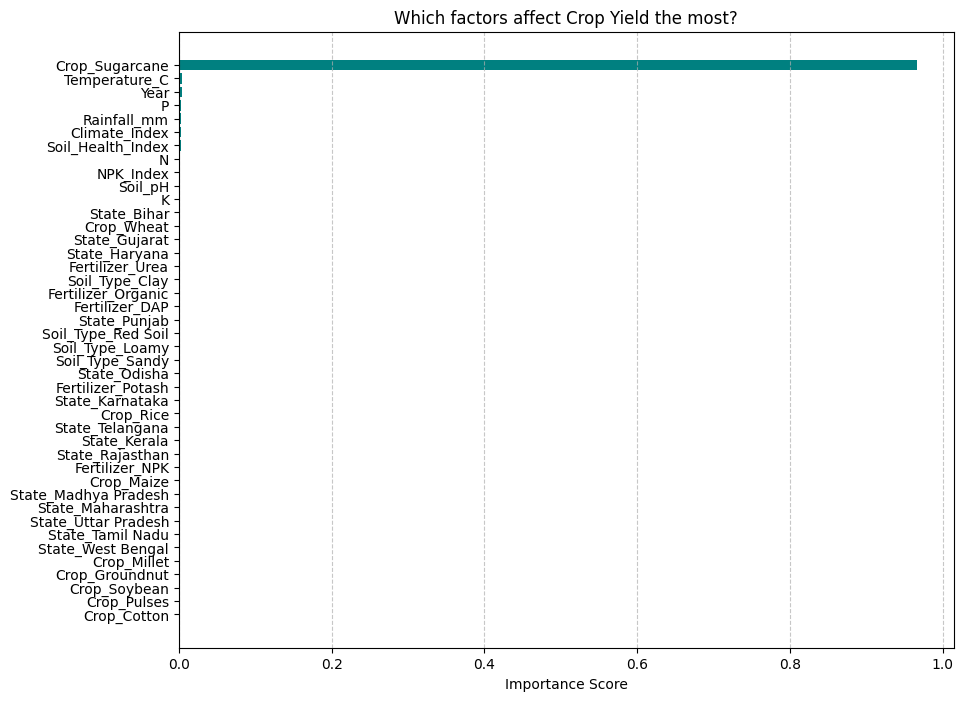

In [21]:
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Which factors affect Crop Yield the most?')
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [22]:
import pickle

with open('crop_yield_model.pkl', 'wb') as file:
    pickle.dump(best_rf, file)

print("Best model (Random Forest) saved as 'crop_yield_model.pkl' ✅")

Best model (Random Forest) saved as 'crop_yield_model.pkl' ✅
